Imports

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna

Utils

In [10]:
PI = torch.pi

def cos(x):
    return np.cos(x)

def sin(x):
    return np.sin(x)

class Function:
    def __init__(self, f, gradient):
        self.ob_f = f
        self.ob_gradient = gradient

    def f(self, x, y):
        return self.ob_f(x, y)

    def gradient(self, vec):
        return self.ob_gradient(vec[0], vec[1])

def grafica(fun: Function):
    x = np.linspace(-1e1,1e1,400)
    y = np.linspace(-1e1,1e1,400)
    X,Y = np.meshgrid(x,y)
    Z = fun.f(X,Y)

    fig1 = plt.figure()
    ax1 = fig1.add_subplot(111, projection='3d')
    ax1.plot_surface(X, Y, Z, cmap='viridis')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    plt.title("Superficie")

    fig2 = plt.figure()
    plt.contour(X, Y, Z, levels=25, cmap='plasma')
    plt.colorbar()
    plt.title("Contour")
    plt.xlabel('x')
    plt.ylabel('y')

    plt.show()

Funcion 0

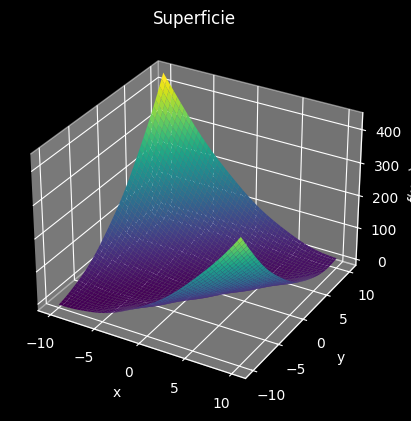

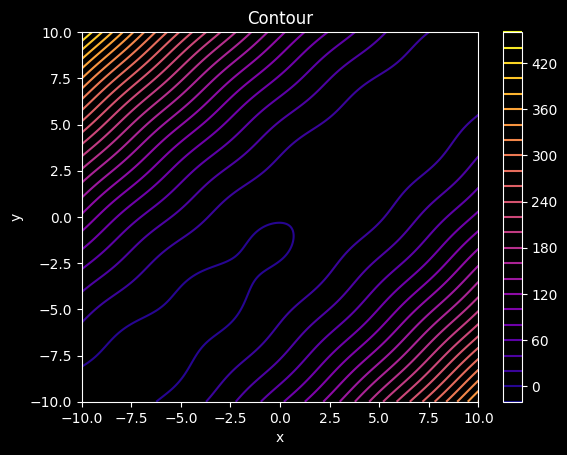

In [11]:
def f0(x, y):
    return sin(x + y) + (x - y) ** 2 - 1.5 * x + 2.5 * y + 1

def gradient0(x, y):
    nx = x * (torch.cos(x + y) + 2*x - 2*y) - 1.5
    ny = y * (torch.cos(x + y) - 2*x + 2*y) + 2.5
    return torch.tensor([nx, ny])

func0 = Function(f0,gradient0)
grafica(func0)

Funcion 1

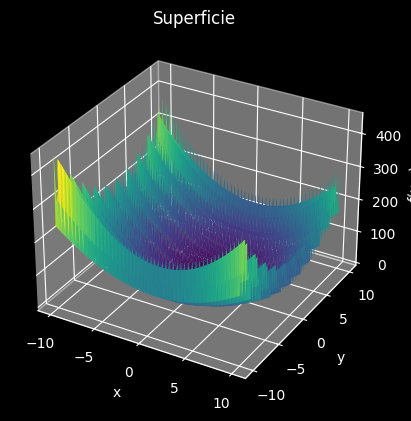

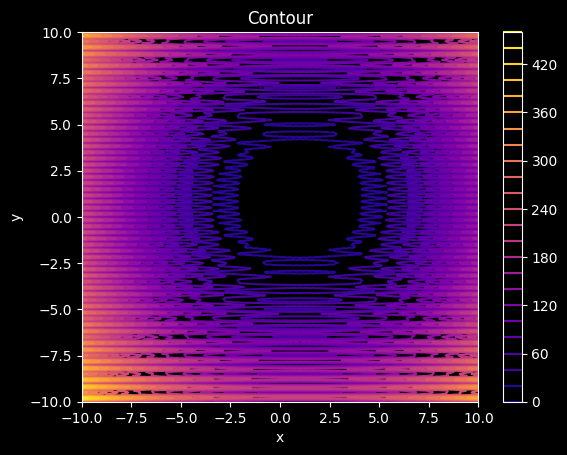

In [12]:
def gradient1(v):
    x = v[0]
    y = v[1]
    nx = (6*PI*sin(3*PI*x)*cos(3*PI*x))+(2*(x-1)*(1+(sin(3*PI*y)**2)))
    ny = ((x-1)**2)*(6*PI*sin(3*PI*y)*cos(3*PI*y))+(2*(y-1)*(1+(sin(2*PI*y)**2)))+((y-1)**2)*(4*PI*sin(2*PI*x)*cos(2*PI*x))
    return torch.tensor([nx, ny])

def f1(x,y):
    return (sin(3 * PI * x) ** 2) + ((x - 1) ** 2) * (1 + (sin(3 * PI * y) ** 2)) + ((y - 1) ** 2) * (1 + sin(2 * PI * y) ** 2)

func1 = Function(f1,gradient1)
grafica(func1)

Funcion 2

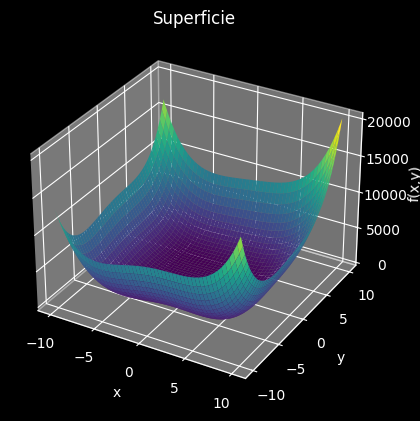

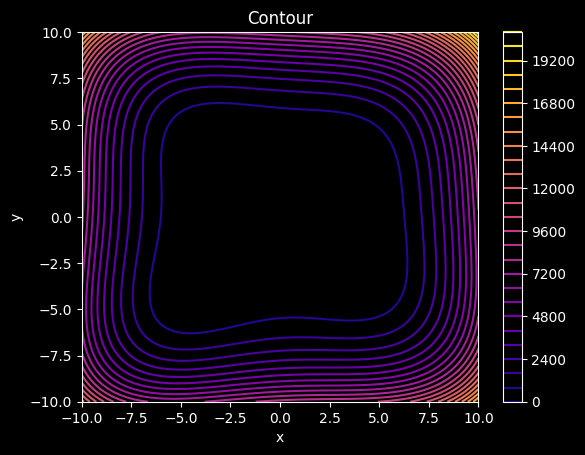

In [13]:
def gradient2(v):
    x = v[0]
    y = v[1]
    nx = 2*(2*x*((x**2)+y-11)+(x+(y**2)-7))
    ny = 2*(((x**2)+y-11)+2*y*(x-(y**2)-7))
    return torch.tensor([nx, ny])

def f2(x,y):
    return ((x * x + y - 11) ** 2) + ((x + y * y - 7) ** 2)

func2 = Function(f2,gradient2)
grafica(func2)

Descenso Gradiente

In [14]:
def gradient_descent(it:int, alpha:float, x0, fun: Function):
    x=[]
    y=[]
    for i in range(it):
        x0=x0-alpha*fun.gradient(x0)
        x.append(x0)
        y.append(fun.f(x0[0], x0[1]))
    return x, y

def objective(trial, fun: Function):
    alpha=trial.suggest_float("alpha", 0, 1, log=True)
    return